In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import importlib

import pickle

import sys
sys.path.append("../../")
import methods  
importlib.reload(methods)

from decision_rules import *

In [47]:
method_names =  {
    'naive_pval': '$p < 0.05$',
    'assure_pval': 'ASSURE $p$-val',
    'cb_pval': 'CB $p$-val',
    'naive_linear_shrink': 'Plug-in Shrinkage',
    'assure_linear_shrink': 'ASSURE Shrinkage',
    'cb_linear_shrink': 'CB Shrinkage',
    'npmle': 'NPMLE',
    'close_npmle': 'CLOSE-NPMLE',
    'close_gauss': 'CLOSE Gauss',
    'assure_close_gauss_cvx': 'Ensemble',
    'assure_close_gauss': 'ASSURE Close-Gauss',
    'fh': 'Fay-Herriot (FH)',
    'assure_fh': 'ASSURE FH',
    'cb_fh': 'CB FH'
}

plotted_methods = [
    #'naive_pval',
    #'assure_pval',
    #'cb_pval',
    'naive_linear_shrink',
    'assure_linear_shrink',
    'cb_linear_shrink',
    'npmle',
    'close_npmle',
    'close_gauss',
    'assure_close_gauss_cvx',
    'assure_close_gauss',
    'fh',
    'assure_fh',
    'cb_fh'
]


In [ ]:
oa_oracle_value = 161.22676342509646
exp_oracle_value = 1.3874965726782422

In [49]:
names = ["OA_comparison_normal_mc_runs40_cost0.361_goodX",
         "OA_comparison_misspecified_mc_runs40_cost0.361_goodX",
         "OA_comparison_normal_mc_runs40_cost0.361_purenoiseX",
         "OA_comparison_misspecified_mc_runs40_cost0.361_purenoiseX",
         "exp_program_comparison_normal_mc_runs50_goodX",
         "exp_program_comparison_misspecified_mc_runs50_goodX",
         "exp_program_comparison_normal_mc_runs50_noiseX",
         "exp_program_comparison_misspecified_mc_runs50_noiseX"]

In [50]:

full_results = np.zeros(shape=(8,len(plotted_methods)))

for j in range(4):
   name = names[j]
   load_name = f'../results/oa_analysis/{name}.pkl'

   with open(load_name, 'rb') as f:
      results = pickle.load(f)

   for i,name in enumerate(plotted_methods):
      full_results[j,i] = np.mean(results[name])/oa_oracle_value

for j in range(4,8):
   name = names[j]
   load_name = f'../results/exp_analysis/{name}.pkl'

   with open(load_name, 'rb') as f:
      results = pickle.load(f)

   for i,name in enumerate(plotted_methods):
      if name in results:
         full_results[j,i] = np.mean(results[name])/exp_oracle_value
      else:
         full_results[j,i] = np.NaN

In [ ]:
full_results

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, Normalize

# ----------------------- Grouping you requested -----------------------
groups = [
    #("$p$-value", ['naive_pval', 'assure_pval', 'cb_pval']),
    ("Linear Shrinkage", ['naive_linear_shrink', 'assure_linear_shrink', 'cb_linear_shrink']),
    ("FH", ['fh', 'assure_fh', 'cb_fh']),
    ("NPMLE", ['npmle', 'close_npmle']),
    ("Close-Gauss", ['close_gauss', 'assure_close_gauss']),
    ("Ensemble", ['assure_close_gauss_cvx'])
]

def plot_simulation_heatmap(
    full_results: np.ndarray,
    row_labels=None,
    title='Performance measured by the % of Oracle Value Captured',
    save_path=None
):
    """
    full_results: array-like, shape (n_specs, n_methods) with columns ordered as `plotted_methods`
    row_labels: list of str, length n_specs
    save_path: if provided, saves PNG to this path
    """
    full_results = np.asarray(full_results)
    n_rows, _ = full_results.shape

    # Row labels
    if row_labels is None:
        row_labels = [f"Spec {i+1}" for i in range(n_rows)]

    # Reorder columns by groups (and keep any leftover methods at the end)
    ordered_methods = []
    for _, meths in groups:
        for m in meths:
            if m in plotted_methods:
                ordered_methods.append(m)
    for m in plotted_methods:
        if m not in ordered_methods:
            ordered_methods.append(m)

    col_idx = [plotted_methods.index(m) for m in ordered_methods]
    data = full_results[:, col_idx]
    n_rows, n_cols = data.shape


    def make_maroon_to_many_greens():
        # Positions in [0,1]; we compress reds and allocate more of the scale to greens.
        return LinearSegmentedColormap.from_list(
            "maroon_to_many_greens",
            [
                (0.00, (0.88, 0.76, 0.76)),   # maroon
                (0.12, (0.88, 0.76, 0.76)),   # light pink
                (0.35, (1.00, 1.00, 1.00)),   # white (pivot)
                (0.45, (0.93, 0.98, 0.93)),   # very light green
                (0.55, (0.85, 0.95, 0.85)),
                (0.65, (0.73, 0.90, 0.73)),
                (0.75, (0.60, 0.80, 0.60)),
                (0.85, (0.45, 0.70, 0.45)),
                (0.93, (0.30, 0.60, 0.30)),
                (1.00, (0.00, 0.39, 0.00)),   # dark green
            ],
            N=512,
        )

    cmap = make_maroon_to_many_greens()

    vmin, vmax = np.nanmin(data), np.nanmax(data)

    # Keep white near 0 so the green side gets most of the gradation.
    if vmin < 0 < vmax:
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)

    # Figure sizing scales with table size
    fig_w = max(12, 0.7 * n_cols + 4)
    fig_h = max(4.5, 0.8 * n_rows + 2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    # Mask NaNs so imshow treats them as "bad" values
    plot_data = np.ma.masked_invalid(data)

    # Make NaNs light gray. with_extremes is newer; fall back to set_bad if needed.
    try:
        cmap = cmap.with_extremes(bad=(0.92, 0.92, 0.92))  # light gray
    except AttributeError:
        cmap.set_bad((0.92, 0.92, 0.92))

    im = ax.imshow(plot_data, cmap=cmap, norm=norm, aspect='auto')

    # Axis tick labels
    ax.set_yticks(np.arange(n_rows))
    ax.set_yticklabels(row_labels, fontsize=12, rotation=15)
    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels([method_names.get(m, m) for m in ordered_methods],
                       rotation=60, ha='right', fontsize=11)

    # Light grid
    ax.set_xticks(np.arange(-.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n_rows, 1), minor=True)
    ax.grid(which='minor', color=(0.5, 0.5, 0.5, 0.35), linestyle='-', linewidth=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)

    # Group separators and labels
    group_boundaries = []
    group_centers = []
    start = 0
    group_labels_in_plot = []
    for lbl, meths in groups:
        present = [m for m in meths if m in ordered_methods]
        if not present:
            continue
        count = len(present)
        end = start + count
        group_boundaries.append(end - 0.5)
        group_centers.append(start + (count - 1) / 2.0)
        group_labels_in_plot.append(lbl)
        start = end

    for b in group_boundaries[:-1]:
        ax.vlines(b, -0.5, n_rows - 0.5, color='black', linewidth=2, alpha=0.6)

    trans = ax.get_xaxis_transform()
    for xc, lbl in zip(group_centers, group_labels_in_plot):
        ax.text(xc, 1.02, lbl, transform=trans, ha='center', va='bottom',
                fontsize=12, fontweight='bold')

    # Annotate numbers inside cells; white text when green is dark enough
    def white_text(val):
        return norm(val) > 0.6

    abs_max = np.nanmax(np.abs(data))
    fmt = (lambda x: f"{100*x:.1f}") if abs_max >= 20 else (lambda x: f"{100*x:.1f}")

    for i in range(n_rows):
        for j in range(n_cols):
            val = plot_data[i, j]
            if np.ma.is_masked(val):   # don’t annotate NaNs
                continue
            ax.text(
                j, i, fmt(val),
                ha='center', va='center',
                fontsize=13,
                color=('white' if white_text(val) else 'black')
            )

    ax.set_title(title, pad=28, fontsize=13)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')

    return fig, ax, {"ordered_methods": ordered_methods, "vmin": vmin, "vmax": vmax}


Saved to simulation_results_heatmap.pdf


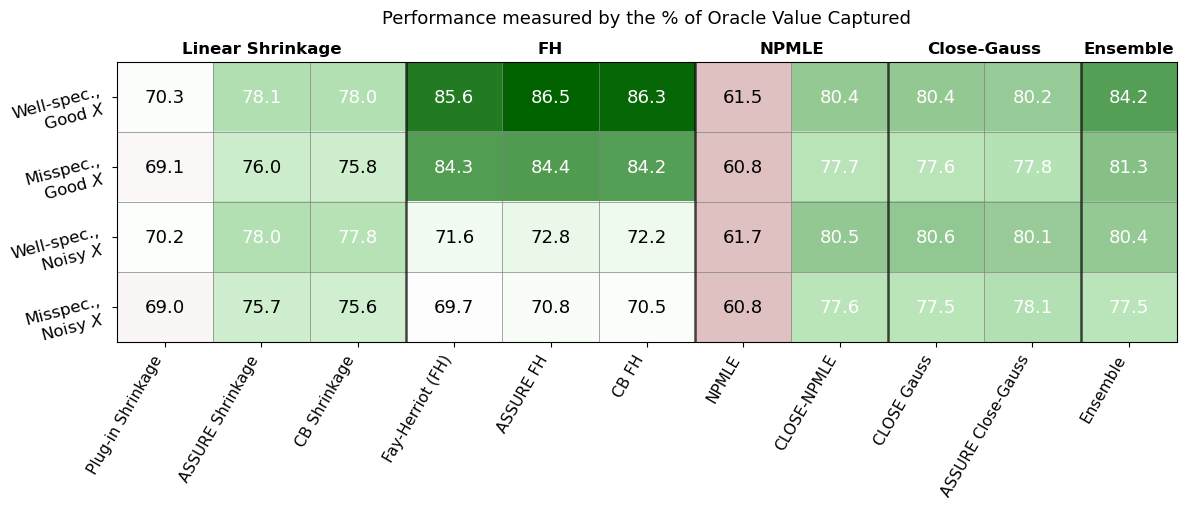

In [ ]:

row_labels = ["Well-spec.,\n Good $X$", "Misspec.,\n Good $X$", "Well-spec.,\n Noisy $X$", "Misspec.,\n Noisy $X$"]
fig, ax, meta = plot_simulation_heatmap(
    full_results[:4,:],
    row_labels=row_labels,
    save_path="simulation_results_heatmap.pdf"
)
print("Saved to simulation_results_heatmap.pdf")
plt.show()